# Vector RAG Matcher - Embedding Model & Similarity Search

This notebook demonstrates how we map resume portfolio projects and job descriptions into a shared semantic vector space. We load a local 384-dimensional SentenceTransformer model (`all-MiniLM-L6-v2`), extract document embeddings, and project them into 2D space using PCA for semantic clustering visualization.

In [1]:
import os
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

C:\Users\Vansh Agrawal\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\Vansh Agrawal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 1. Load Local Embedding Model

We initialize `all-MiniLM-L6-v2`. This model is lightweight (~80MB), runs entirely on CPU/GPU locally, and encodes text into 384-dimensional dense vectors representing contextual semantics.

In [2]:
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Embedding Model Dimension:", model.get_sentence_embedding_dimension())

C:\Users\Vansh Agrawal\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Vansh Agrawal\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Embedding Model Dimension: 384


## 2. Generate Embeddings for Projects & Queries

In [3]:
# Sample candidate project records
portfolio_projects = [
    {"title": "LitterVision", "text": "YOLOv8 target detection PyTorch pipeline for city waste identification and DCGAN generator.", "category": "Computer Vision"},
    {"title": "QuakeIntel", "text": "Real-time seismic visualizer React application with Three.js webGL globe and GIS map integration.", "category": "Frontend/GIS"},
    {"title": "VinoMetrix", "text": "FastAPI backend using XGBoost machine learning to predict wine quality based on chemical features.", "category": "ML/Backend"},
    {"title": "AuthSecure", "text": "OAuth2 authentication microservice in Go with JWT validation and rate limiting middleware.", "category": "Backend/Security"}
]

# Compute embeddings
project_texts = [p["text"] for p in portfolio_projects]
project_embeddings = model.encode(project_texts)

print(f"Encoded {len(project_embeddings)} projects. Shape: {project_embeddings.shape}")

Encoded 4 projects. Shape: (4, 384)


## 3. Query Similarity Matching

We calculate the cosine similarity between a target job description query and our portfolio projects to rank alignment.

In [4]:
jd_query = "Seeking a React developer with WebGL and spatial visualization experience for building geographical mapping portals."
query_embedding = model.encode([jd_query])[0]

# Calculate cosine similarity: (A . B) / (||A|| * ||B||)
similarities = []
for idx, emb in enumerate(project_embeddings):
    cos_sim = np.dot(query_embedding, emb) / (np.linalg.norm(query_embedding) * np.linalg.norm(emb))
    similarities.append({
        "project": portfolio_projects[idx]["title"],
        "similarity": cos_sim,
        "category": portfolio_projects[idx]["category"]
    })

df_results = pd.DataFrame(similarities).sort_values(by="similarity", ascending=False)
df_results

,project,similarity,category
1,QuakeIntel,0.680536,Frontend/GIS
0,LitterVision,0.061532,Computer Vision
2,VinoMetrix,0.025375,ML/Backend
3,AuthSecure,-0.009111,Backend/Security


## 4. PCA Projection Visualization

We project the high-dimensional vectors (384-D) onto 2D space using Principal Component Analysis (PCA) to visualize structural distance and similarity.

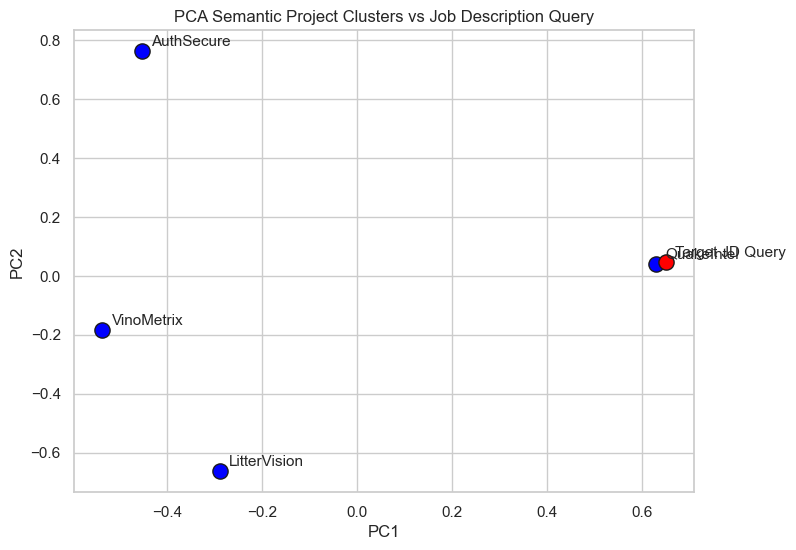

In [5]:
all_vectors = np.vstack([project_embeddings, query_embedding])
pca = PCA(n_components=2)
projected = pca.fit_transform(all_vectors)

labels = [p["title"] for p in portfolio_projects] + ["Target JD Query"]
colors = ["blue"] * len(portfolio_projects) + ["red"]

plt.figure(figsize=(8, 6))
for i in range(len(labels)):
    plt.scatter(projected[i, 0], projected[i, 1], c=colors[i], s=120, edgecolors='k')
    plt.text(projected[i, 0] + 0.02, projected[i, 1] + 0.02, labels[i], fontsize=11)

plt.title("PCA Semantic Project Clusters vs Job Description Query")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("../models/vector_rag_pca.png")
plt.show()